In [1]:
import os, torch, torch.nn as nn, torch.nn.functional as F
import numpy as np, matplotlib.pyplot as plt
from tqdm import tqdm
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, WeightedRandomSampler, Dataset
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, roc_curve, precision_score, recall_score
)
import timm, pennylane as qml
from PIL import Image

torch.set_default_dtype(torch.float32)
DEVICE   = 'cuda' if torch.cuda.is_available() else 'cpu'
DATA_DIR = 'heart_balanced'   # ← change to your path
print('Using:', DEVICE)

Using: cpu


In [2]:
base_ds = datasets.ImageFolder(DATA_DIR)
CLASS_TO_IDX = base_ds.class_to_idx      # e.g. {'abnormal': 0, 'normal': 1}
IDX_TO_CLASS = {v: k for k, v in CLASS_TO_IDX.items()}
ABNORMAL_IDX = CLASS_TO_IDX['abnormal']  # will be 0
NORMAL_IDX   = CLASS_TO_IDX['normal']    # will be 1

print('class_to_idx:', CLASS_TO_IDX)
print('ABNORMAL_IDX:', ABNORMAL_IDX, ' | NORMAL_IDX:', NORMAL_IDX)
# ✅ Must show: abnormal=0, normal=1
# If flipped, rename folders so 'abnormal' comes first alphabetically

targets = np.array(base_ds.targets)
print('Total samples:', len(targets))
print('Abnormal:', (targets == ABNORMAL_IDX).sum(), ' | Normal:', (targets == NORMAL_IDX).sum())

class_to_idx: {'abnormal': 0, 'normal': 1}
ABNORMAL_IDX: 0  | NORMAL_IDX: 1
Total samples: 380
Abnormal: 200  | Normal: 180


In [3]:
# Medical-safe augmentation: no drastic distortions
train_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(10),           # keep low for ultrasound
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

val_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

# This is also what we use at inference time
infer_tf = val_tf

In [4]:
class TransformSubset(Dataset):
    def __init__(self, dataset, indices, transform):
        self.dataset   = dataset
        self.indices   = indices
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        img, label = self.dataset[self.indices[i]]
        return self.transform(img), label


def make_weighted_loader(dataset, labels, batch_size, shuffle=False):
    """Weighted sampler so every batch has balanced classes."""
    class_counts   = np.bincount(labels)
    sample_weights = (1.0 / class_counts)[labels]
    sampler = WeightedRandomSampler(
        torch.from_numpy(sample_weights).float(),
        num_samples=len(sample_weights),
        replacement=True
    )
    return DataLoader(dataset, batch_size=batch_size, sampler=sampler)


def get_kfold_loaders(fold, k=5, batch_size=8):
    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
    splits = list(skf.split(np.zeros(len(targets)), targets))
    train_idx, val_idx = splits[fold]

    train_ds = TransformSubset(base_ds, train_idx, train_tf)  # augmented
    val_ds   = TransformSubset(base_ds, val_idx,   val_tf)    # clean

    train_labels = targets[train_idx]
    class_counts = np.bincount(train_labels)
    print(f'  Fold {fold+1}: train={len(train_idx)}, val={len(val_idx)}, '
          f'train_abnormal={class_counts[ABNORMAL_IDX]}, train_normal={class_counts[NORMAL_IDX]}')

    train_loader = make_weighted_loader(train_ds, train_labels, batch_size)
    val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    return train_loader, val_loader


def get_full_train_loader(batch_size=8):
    """Used for final retraining on the entire dataset after CV."""
    full_ds = TransformSubset(base_ds, np.arange(len(base_ds)), train_tf)
    return make_weighted_loader(full_ds, targets, batch_size)

In [5]:
class QuantumLayer(nn.Module):
    def __init__(self, n_qubits=6, n_layers=3):
        super().__init__()
        self.n_qubits = n_qubits
        dev = qml.device('default.qubit', wires=n_qubits)

        @qml.qnode(dev, interface='torch', diff_method='backprop')
        def circuit(inputs, weights):
            # Amplitude encoding via RY
            for i in range(n_qubits):
                qml.RY(inputs[i], wires=i)
            # Variational layers
            for l in range(n_layers):
                for i in range(n_qubits):
                    qml.RX(weights[l, i, 0], wires=i)
                    qml.RY(weights[l, i, 1], wires=i)
                # Ring entanglement
                for i in range(n_qubits - 1):
                    qml.CNOT(wires=[i, i+1])
                qml.CNOT(wires=[n_qubits-1, 0])
            return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

        self.circuit  = circuit
        # Slightly larger init so gradients flow better from the start
        self.q_params = nn.Parameter(0.1 * torch.randn(n_layers, n_qubits, 2))

    def forward(self, x):
        return torch.stack([
            torch.stack(self.circuit(x[b], self.q_params)).to(torch.float32)
            for b in range(x.shape[0])
        ])


class QuantumMixingBlock(nn.Module):
    def __init__(self, in_dim, n_qubits=6):
        super().__init__()
        self.pre    = nn.Linear(in_dim, n_qubits)
        self.bn     = nn.BatchNorm1d(n_qubits)   # stabilize before quantum
        self.quantum = QuantumLayer(n_qubits=n_qubits)
        self.post   = nn.Linear(n_qubits, in_dim)
        self.drop   = nn.Dropout(0.3)

    def forward(self, x):
        q_in  = self.bn(self.pre(x))
        q_in  = F.normalize(q_in, dim=1) * np.pi  # map to [-π, π]
        q_out = self.quantum(q_in)
        return self.drop(self.post(q_out)) + x    # residual


class HybridViT(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.backbone = timm.create_model(
            'vit_tiny_patch16_224', pretrained=True, num_classes=0
        )
        embed_dim   = self.backbone.num_features   # 192 for vit_tiny
        self.qblock = QuantumMixingBlock(embed_dim)
        self.head   = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, num_classes)
        )

    def forward(self, x):
        feats = self.backbone(x)
        feats = self.qblock(feats)
        return self.head(feats)


def build_model():
    model = HybridViT().to(DEVICE)
    # Freeze backbone initially, train head + quantum only
    for p in model.backbone.parameters():
        p.requires_grad = False
    return model


def build_optimizer(model):
    return torch.optim.AdamW([
        {'params': model.backbone.parameters(), 'lr': 5e-6},
        {'params': model.qblock.parameters(),   'lr': 1e-4},
        {'params': model.head.parameters(),     'lr': 1e-4},
    ], weight_decay=1e-4)


# ✅ FIX: weighted loss to further reinforce class balance at the loss level
# abnormal is minority so we give it higher weight
def build_criterion():
    n_abnormal = (targets == ABNORMAL_IDX).sum()
    n_normal   = (targets == NORMAL_IDX).sum()
    # weight for each class: inversely proportional to frequency
    w = torch.tensor([n_normal / n_abnormal, 1.0], dtype=torch.float32).to(DEVICE)
    print(f'Loss weights: abnormal={w[0]:.2f}, normal={w[1]:.2f}')
    return nn.CrossEntropyLoss(weight=w)

In [6]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    losses = []
    for imgs, labels in tqdm(loader, leave=False):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(imgs), labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        losses.append(loss.item())
    return np.mean(losses)


def evaluate(model, loader, criterion):
    model.eval()
    y_true, y_pred, y_prob, losses = [], [], [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            out   = model(imgs)
            probs = torch.softmax(out, dim=1)

            # ✅ FIX: Use ABNORMAL_IDX as positive class consistently everywhere
            prob_abnormal = probs[:, ABNORMAL_IDX]   # probability of being abnormal

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(torch.argmax(out, 1).cpu().numpy())
            y_prob.extend(prob_abnormal.cpu().numpy())   # prob of positive class
            losses.append(criterion(out, labels).item())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_prob = np.array(y_prob)

    # AUC: positive label is ABNORMAL_IDX (0)
    auc = roc_auc_score((y_true == ABNORMAL_IDX).astype(int), y_prob)

    return {
        'loss':      np.mean(losses),
        'acc':       accuracy_score(y_true, y_pred),
        'f1':        f1_score(y_true, y_pred, pos_label=ABNORMAL_IDX, zero_division=0),
        'recall':    recall_score(y_true, y_pred, pos_label=ABNORMAL_IDX, zero_division=0),
        'precision': precision_score(y_true, y_pred, pos_label=ABNORMAL_IDX, zero_division=0),
        'auc':       auc,
        'cm':        confusion_matrix(y_true, y_pred),
        'y_true':    y_true,
        'y_prob':    y_prob,
    }

 ## Cross-validation 

In [7]:
NUM_FOLDS  = 5
EPOCHS     = 15
UNFREEZE_AT = 4   # epoch to unfreeze backbone
BATCH_SIZE = 8

all_results = []
all_y_true  = []
all_y_prob  = []

criterion = build_criterion()

for fold in range(NUM_FOLDS):
    print(f'\n======= FOLD {fold+1}/{NUM_FOLDS} =======')
    train_loader, val_loader = get_kfold_loaders(fold, batch_size=BATCH_SIZE)

    model     = build_model()
    optimizer = build_optimizer(model)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    best_auc         = 0.0
    best_fold_state  = None
    patience_counter = 0
    PATIENCE         = 5

    for epoch in range(EPOCHS):
        if epoch == UNFREEZE_AT:
            print('  >> Unfreezing backbone')
            for p in model.backbone.parameters():
                p.requires_grad = True

        loss    = train_one_epoch(model, train_loader, criterion, optimizer)
        metrics = evaluate(model, val_loader, criterion)
        scheduler.step()

        print(f'  Epoch {epoch+1:2d}: loss={loss:.4f} '
              f'acc={metrics["acc"]:.4f} auc={metrics["auc"]:.4f} '
              f'recall={metrics["recall"]:.4f} f1={metrics["f1"]:.4f}')
        print(f'  CM: {metrics["cm"].tolist()}')

        if metrics['auc'] > best_auc:
            best_auc        = metrics['auc']
            best_fold_state = {k: v.clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print(f'  Early stop at epoch {epoch+1}')
                break

    # Evaluate best state for this fold
    model.load_state_dict(best_fold_state)
    final_metrics = evaluate(model, val_loader, criterion)
    all_results.append(final_metrics)
    all_y_true.extend(final_metrics['y_true'])
    all_y_prob.extend(final_metrics['y_prob'])
    print(f'  Best fold AUC: {best_auc:.4f}')

# Aggregate CV results
print('\n====== CROSS-VALIDATION SUMMARY ======')
for metric in ['acc', 'auc', 'f1', 'recall', 'precision']:
    vals = [r[metric] for r in all_results]
    print(f'{metric:10s}: {np.mean(vals):.4f} ± {np.std(vals):.4f}')

Loss weights: abnormal=0.90, normal=1.00

======= FOLD 1/5 =======
  Fold 1: train=304, val=76, train_abnormal=160, train_normal=144


  Epoch  1: loss=0.6727 acc=0.5526 auc=0.5382 recall=0.6500 f1=0.6047
  CM: [[26, 14], [20, 16]]


  Epoch  2: loss=0.6497 acc=0.5789 auc=0.6062 recall=0.4500 f1=0.5294
  CM: [[18, 22], [10, 26]]


  Epoch  3: loss=0.6372 acc=0.5789 auc=0.6563 recall=0.4000 f1=0.5000
  CM: [[16, 24], [8, 28]]


  Epoch  4: loss=0.6299 acc=0.6579 auc=0.6972 recall=0.5750 f1=0.6389
  CM: [[23, 17], [9, 27]]
  >> Unfreezing backbone


...

  Epoch 11: loss=0.2431 acc=0.8289 auc=0.9868 recall=0.6750 f1=0.8060
  CM: [[27, 13], [0, 36]]


  Epoch 12: loss=0.2217 acc=0.8026 auc=0.9868 recall=0.6250 f1=0.7692
  CM: [[25, 15], [0, 36]]


  Epoch 13: loss=0.2629 acc=0.8289 auc=0.9868 recall=0.6750 f1=0.8060
  CM: [[27, 13], [0, 36]]


  Epoch 14: loss=0.1785 acc=0.8421 auc=0.9868 recall=0.7000 f1=0.8235
  CM: [[28, 12], [0, 36]]


  Epoch 15: loss=0.1560 acc=0.8289 auc=0.9868 recall=0.6750 f1=0.8060
  CM: [[27, 13], [0, 36]]
  Best fold AUC: 0.9868

====== CROSS-VALIDATION SUMMARY ======
acc       : 0.8579 ± 0.0226
auc       : 0.9639 ± 0.0177
f1        : 0.8442 ± 0.0279
recall    : 0.7350 ± 0.0406
precision : 0.9933 ± 0.0133


Optimal threshold (Youden): 0.1145
At this threshold — TPR (sensitivity): 0.9100, FPR (1-specificity): 0.0611


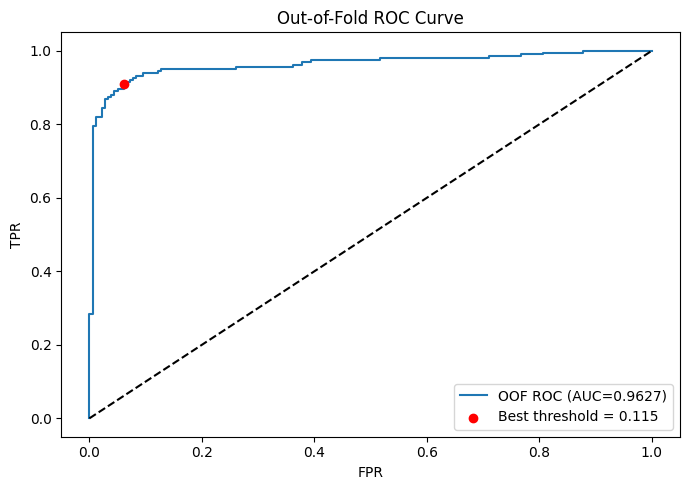

In [8]:
all_y_true = np.array(all_y_true)
all_y_prob = np.array(all_y_prob)

# Convert to binary: 1 = abnormal (positive class), 0 = normal
binary_true = (all_y_true == ABNORMAL_IDX).astype(int)

fpr, tpr, thresholds = roc_curve(binary_true, all_y_prob)
youden_idx   = np.argmax(tpr - fpr)
BEST_THRESH  = float(thresholds[youden_idx])

print(f'Optimal threshold (Youden): {BEST_THRESH:.4f}')
print(f'At this threshold — TPR (sensitivity): {tpr[youden_idx]:.4f}, '
      f'FPR (1-specificity): {fpr[youden_idx]:.4f}')

# Plot ROC
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f'OOF ROC (AUC={roc_auc_score(binary_true, all_y_prob):.4f})')
plt.scatter(fpr[youden_idx], tpr[youden_idx], color='red', zorder=5,
            label=f'Best threshold = {BEST_THRESH:.3f}')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('FPR'); plt.ylabel('TPR')
plt.title('Out-of-Fold ROC Curve')
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
# Use the mean best epoch from CV as a guide (or just set FINAL_EPOCHS manually)
FINAL_EPOCHS = 12

print('=== Training final model on full dataset ===')
full_loader = get_full_train_loader(batch_size=BATCH_SIZE)

final_model     = build_model()
final_optimizer = build_optimizer(final_model)
final_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(final_optimizer, T_max=FINAL_EPOCHS)
final_criterion = build_criterion()

for epoch in range(FINAL_EPOCHS):
    if epoch == UNFREEZE_AT:
        print('  >> Unfreezing backbone')
        for p in final_model.backbone.parameters():
            p.requires_grad = True

    loss = train_one_epoch(final_model, full_loader, final_criterion, final_optimizer)
    final_scheduler.step()
    print(f'  Epoch {epoch+1:2d}: loss={loss:.4f}')

torch.save({
    'model_state':  final_model.state_dict(),
    'class_to_idx': CLASS_TO_IDX,
    'threshold':    BEST_THRESH,
}, 'qvit_final_model.pth')

print(f'\n✅ Final model saved with threshold={BEST_THRESH:.4f}')

=== Training final model on full dataset ===
Loss weights: abnormal=0.90, normal=1.00


  Epoch  1: loss=0.7257


  Epoch  2: loss=0.6892


  Epoch  3: loss=0.6709


  Epoch  4: loss=0.6353
  >> Unfreezing backbone


...

  Epoch  8: loss=0.2653


  Epoch  9: loss=0.2384


  Epoch 10: loss=0.2469


  Epoch 11: loss=0.2657


  Epoch 12: loss=0.2265

✅ Final model saved with threshold=0.1145


In [101]:
def load_model_for_inference(checkpoint_path='qvit_final_model.pth'):
    ckpt         = torch.load(checkpoint_path, map_location=DEVICE)
    class_to_idx = ckpt['class_to_idx']
    threshold    = ckpt['threshold']

    model = HybridViT(num_classes=2)
    model.load_state_dict(ckpt['model_state'])
    model.to(DEVICE)
    model.eval()

    abnormal_idx = class_to_idx['abnormal']
    print(f'Loaded model | class_to_idx: {class_to_idx} | threshold: {threshold:.4f}')
    return model, class_to_idx, abnormal_idx, threshold


infer_model, infer_class_to_idx, infer_abnormal_idx, infer_threshold = \
    load_model_for_inference()

C:\Users\nishu\AppData\Local\Temp\ipykernel_9528\1060514116.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt         = torch.load(checkpoint_path, map_location=DEVIC

Loaded model | class_to_idx: {'abnormal': 0, 'normal': 1} | threshold: 0.1145


In [116]:
for name, param in model.named_parameters():
    print(name, param.abs().mean().item())
    break

backbone.cls_token 0.25392431020736694


In [126]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import pennylane as qml
import timm

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# --- 1. Model Definitions (Copied directly to avoid triggering training on import) ---
class QuantumLayer(nn.Module):
    def __init__(self, n_qubits=6, n_layers=3):
        super().__init__()
        self.n_qubits = n_qubits
        dev = qml.device('default.qubit', wires=n_qubits)
        @qml.qnode(dev, interface='torch', diff_method='backprop')
        def circuit(inputs, weights):
            for i in range(n_qubits): qml.RY(inputs[i], wires=i)
            for l in range(n_layers):
                for i in range(n_qubits):
                    qml.RX(weights[l, i, 0], wires=i)
                    qml.RY(weights[l, i, 1], wires=i)
                for i in range(n_qubits - 1): qml.CNOT(wires=[i, i+1])
                qml.CNOT(wires=[n_qubits-1, 0])
            return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]
        self.circuit  = circuit
        self.q_params = nn.Parameter(0.1 * torch.randn(n_layers, n_qubits, 2))
    def forward(self, x):
        return torch.stack([torch.stack(self.circuit(x[b], self.q_params)).to(torch.float32) for b in range(x.shape[0])])

class QuantumMixingBlock(nn.Module):
    def __init__(self, in_dim, n_qubits=6):
        super().__init__()
        self.pre    = nn.Linear(in_dim, n_qubits)
        self.bn     = nn.BatchNorm1d(n_qubits)
        self.quantum = QuantumLayer(n_qubits=n_qubits)
        self.post   = nn.Linear(n_qubits, in_dim)
        self.drop   = nn.Dropout(0.3)
    def forward(self, x):
        q_in  = self.bn(self.pre(x))
        q_in  = F.normalize(q_in, dim=1) * torch.pi
        q_out = self.quantum(q_in)
        return self.drop(self.post(q_out)) + x

class HybridViT(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        # Pretrained = False because we are loading weights from checkpoint anyway
        self.backbone = timm.create_model('vit_tiny_patch16_224', pretrained=False, num_classes=0)
        embed_dim   = self.backbone.num_features
        self.qblock = QuantumMixingBlock(embed_dim)
        self.head   = nn.Sequential(nn.LayerNorm(embed_dim), nn.Linear(embed_dim, num_classes))
    def forward(self, x):
        return self.head(self.qblock(self.backbone(x)))

infer_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

# --- 2. Inference Logic ---
def load_inference_model(checkpoint_path='qvit_final_model.pth'):
    # Weights_only=False suppresses a warning as the model object is saved in older torch loops
    import warnings
    warnings.filterwarnings("ignore", category=FutureWarning)
    
    ckpt = torch.load(checkpoint_path, map_location=DEVICE)
    class_to_idx = ckpt['class_to_idx']
    threshold = ckpt['threshold']
    
    model = HybridViT(num_classes=2)
    model.load_state_dict(ckpt['model_state'])
    model.to(DEVICE)
    model.eval() # Ensure dropout & batchnorm are in inference mode
    
    return model, class_to_idx, threshold

def predict_single_image(img_path, model, class_to_idx, threshold):
    abnormal_idx = class_to_idx['abnormal']
    
    img = Image.open(img_path).convert('RGB')
    x = infer_tf(img).unsqueeze(0).to(DEVICE)
    
    with torch.no_grad():
        logits = model(x)
        probs = torch.softmax(logits, dim=1)[0]
        
    prob_abnormal = probs[abnormal_idx].item()
    prob_normal = probs[1 - abnormal_idx].item()
    
    # ✅ FIX: probability needs to be GREATER THAN OR EQUAL TO the threshold!
    if prob_abnormal >= threshold:
        label = 'ABNORMAL'
        confidence = prob_abnormal
    else:
        label = 'normal'
        confidence = prob_normal
        
    print(f"File: {os.path.basename(img_path)}")
    print(f"  prob_abnormal={prob_abnormal:.4f} | prob_normal={prob_normal:.4f} | threshold={threshold:.4f}")
    print(f"  → Prediction: {label} ({confidence:.2%})")
    print("-" * 40)
    
    return label, confidence

if __name__ == '__main__':
    model, c2i, thresh = load_inference_model('qvit_final_model.pth')

In [132]:
 # Test on one abnormal and one normal image to verify
print("--- Using Calibrated Threshold Inference ---")
predict_single_image('heart_balanced/abnormal/193_aug1.png', model, c2i, thresh)
predict_single_image('heart_balanced/normal/038.png', model, c2i, thresh)

--- Using Calibrated Threshold Inference ---
File: 193_aug1.png
  prob_abnormal=0.8978 | prob_normal=0.1022 | threshold=0.1145
  → Prediction: ABNORMAL (89.78%)
----------------------------------------
File: 038.png
  prob_abnormal=0.0721 | prob_normal=0.9279 | threshold=0.1145
  → Prediction: normal (92.79%)
----------------------------------------


('normal', 0.9278818964958191)

In [134]:
 # Test on one abnormal and one normal image to verify
print("--- Using Calibrated Threshold Inference ---")
predict_single_image('heart_balanced/abnormal/016_aug1.png', model, c2i, thresh)
predict_single_image('heart_balanced/normal/004.png', model, c2i, thresh)

--- Using Calibrated Threshold Inference ---
File: 016_aug1.png
  prob_abnormal=0.8440 | prob_normal=0.1560 | threshold=0.1145
  → Prediction: ABNORMAL (84.40%)
----------------------------------------
File: 004.png
  prob_abnormal=0.0282 | prob_normal=0.9718 | threshold=0.1145
  → Prediction: normal (97.18%)
----------------------------------------


('normal', 0.9718001484870911)

In [135]:
 # Test on one abnormal and one normal image to verify
print("--- Using Calibrated Threshold Inference ---")
predict_single_image('heart_balanced/abnormal/026_aug3.png', model, c2i, thresh)
predict_single_image('heart_balanced/normal/054.png', model, c2i, thresh)

--- Using Calibrated Threshold Inference ---
File: 026_aug3.png
  prob_abnormal=0.6366 | prob_normal=0.3634 | threshold=0.1145
  → Prediction: ABNORMAL (63.66%)
----------------------------------------
File: 054.png
  prob_abnormal=0.0394 | prob_normal=0.9606 | threshold=0.1145
  → Prediction: normal (96.06%)
----------------------------------------


('normal', 0.9606339335441589)

In [1]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import pennylane as qml
import timm

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# --- 1. Model Definitions (Copied directly to avoid triggering training on import) ---
class QuantumLayer(nn.Module):
    def __init__(self, n_qubits=6, n_layers=3):
        super().__init__()
        self.n_qubits = n_qubits
        dev = qml.device('default.qubit', wires=n_qubits)
        @qml.qnode(dev, interface='torch', diff_method='backprop')
        def circuit(inputs, weights):
            for i in range(n_qubits): qml.RY(inputs[i], wires=i)
            for l in range(n_layers):
                for i in range(n_qubits):
                    qml.RX(weights[l, i, 0], wires=i)
                    qml.RY(weights[l, i, 1], wires=i)
                for i in range(n_qubits - 1): qml.CNOT(wires=[i, i+1])
                qml.CNOT(wires=[n_qubits-1, 0])
            return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]
        self.circuit  = circuit
        self.q_params = nn.Parameter(0.1 * torch.randn(n_layers, n_qubits, 2))
    def forward(self, x):
        return torch.stack([torch.stack(self.circuit(x[b], self.q_params)).to(torch.float32) for b in range(x.shape[0])])

class QuantumMixingBlock(nn.Module):
    def __init__(self, in_dim, n_qubits=6):
        super().__init__()
        self.pre    = nn.Linear(in_dim, n_qubits)
        self.bn     = nn.BatchNorm1d(n_qubits)
        self.quantum = QuantumLayer(n_qubits=n_qubits)
        self.post   = nn.Linear(n_qubits, in_dim)
        self.drop   = nn.Dropout(0.3)
    def forward(self, x):
        q_in  = self.bn(self.pre(x))
        q_in  = F.normalize(q_in, dim=1) * torch.pi
        q_out = self.quantum(q_in)
        return self.drop(self.post(q_out)) + x

class HybridViT(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        # Pretrained = False because we are loading weights from checkpoint anyway
        self.backbone = timm.create_model('vit_tiny_patch16_224', pretrained=False, num_classes=0)
        embed_dim   = self.backbone.num_features
        self.qblock = QuantumMixingBlock(embed_dim)
        self.head   = nn.Sequential(nn.LayerNorm(embed_dim), nn.Linear(embed_dim, num_classes))
    def forward(self, x):
        return self.head(self.qblock(self.backbone(x)))

infer_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

# --- 2. Inference Logic ---
def load_inference_model(checkpoint_path='qvit_final_model.pth'):
    # Weights_only=False suppresses a warning as the model object is saved in older torch loops
    import warnings
    warnings.filterwarnings("ignore", category=FutureWarning)
    
    ckpt = torch.load(checkpoint_path, map_location=DEVICE)
    class_to_idx = ckpt['class_to_idx']
    threshold = ckpt['threshold']
    
    model = HybridViT(num_classes=2)
    model.load_state_dict(ckpt['model_state'])
    model.to(DEVICE)
    model.eval() # Ensure dropout & batchnorm are in inference mode
    
    return model, class_to_idx, threshold

def predict_single_image(img_path, model, class_to_idx, threshold):
    abnormal_idx = class_to_idx['abnormal']
    
    img = Image.open(img_path).convert('RGB')
    x = infer_tf(img).unsqueeze(0).to(DEVICE)
    
    with torch.no_grad():
        logits = model(x)
        probs = torch.softmax(logits, dim=1)[0]
        
    prob_abnormal = probs[abnormal_idx].item()
    prob_normal = probs[1 - abnormal_idx].item()
    
    # ✅ FIX: probability needs to be GREATER THAN OR EQUAL TO the threshold!
    if prob_abnormal >= threshold:
        label = 'ABNORMAL'
        confidence = prob_abnormal
    else:
        label = 'normal'
        confidence = prob_normal
        
    print(f"File: {os.path.basename(img_path)}")
    print(f"  prob_abnormal={prob_abnormal:.4f} | prob_normal={prob_normal:.4f} | threshold={threshold:.4f}")
    print(f"  → Prediction: {label} ({confidence:.2%})")
    print("-" * 40)
    
    return label, confidence

if __name__ == '__main__':
    model, c2i, thresh = load_inference_model('qvit_final_model.pth')

In [4]:
 # Test on one abnormal and one normal image to verify
print("--- Using Calibrated Threshold Inference ---")
predict_single_image('heart_balanced/abnormal/026_aug3.png', model, c2i, thresh)
predict_single_image('heart_balanced/normal/054.png', model, c2i, thresh)

--- Using Calibrated Threshold Inference ---
File: 026_aug3.png
  prob_abnormal=0.6366 | prob_normal=0.3634 | threshold=0.1145
  → Prediction: ABNORMAL (63.66%)
----------------------------------------
File: 054.png
  prob_abnormal=0.0394 | prob_normal=0.9606 | threshold=0.1145
  → Prediction: normal (96.06%)
----------------------------------------


('normal', 0.9606339335441589)

In [9]:
 # Test on one abnormal and one normal image to verify
print("--- Using Calibrated Threshold Inference ---")
predict_single_image('heart_balanced/abnormal/193_aug1.png', model, c2i, thresh)
predict_single_image('heart_balanced/normal/038.png', model, c2i, thresh)

--- Using Calibrated Threshold Inference ---
File: 193_aug1.png
  prob_abnormal=0.8978 | prob_normal=0.1022 | threshold=0.1145
  → Prediction: ABNORMAL (89.78%)
----------------------------------------
File: 038.png
  prob_abnormal=0.0721 | prob_normal=0.9279 | threshold=0.1145
  → Prediction: normal (92.79%)
----------------------------------------


('normal', 0.9278818964958191)

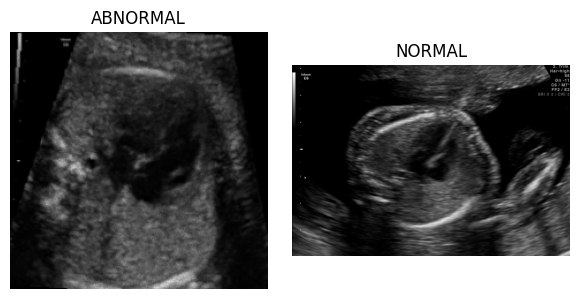

In [17]:
from PIL import Image
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(6, 3))

for ax, path in zip(axes, [
    'heart_balanced/abnormal/026_aug3.png',
    'heart_balanced/normal/054.png'
]):
    img = Image.open(path).convert('RGB')
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(path.split('/')[1].upper())

plt.tight_layout()
plt.show()

Generating Score-CAM for: 004.png
  → Prediction: normal (97.18%)


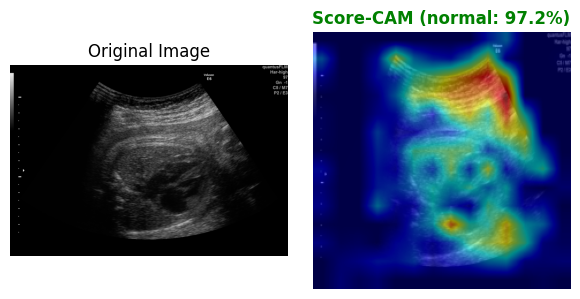

Generating Score-CAM for: 016_aug1.png
  → Prediction: ABNORMAL (84.40%)


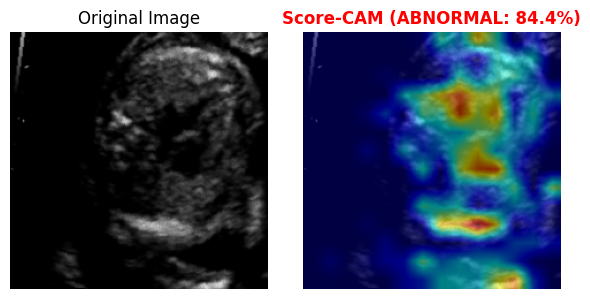

In [15]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Import the standalone model & inference logic we just perfected
from clean_predict import load_inference_model, infer_tf, DEVICE

# Import the ScoreCAM utilities from your src folder
from src.score_cam import ScoreCAM, show_cam_on_image

def generate_scorecam_heatmap(img_path, model, class_to_idx, threshold):
    print(f"Generating Score-CAM for: {os.path.basename(img_path)}")
    
    # 1. Prepare image
    img = Image.open(img_path).convert('RGB')
    input_tensor = infer_tf(img).unsqueeze(0).to(DEVICE)
    
    # 2. Get standard prediction first
    abnormal_idx = class_to_idx['abnormal']
    model.eval()
    with torch.no_grad():
        logits = model(input_tensor)
        probs = torch.softmax(logits, dim=1)[0]
        
    prob_abnormal = probs[abnormal_idx].item()
    if prob_abnormal >= threshold:
        label = 'ABNORMAL'
        confidence = prob_abnormal
    else:
        label = 'normal'
        confidence = probs[1 - abnormal_idx].item()
        
    print(f"  → Prediction: {label} ({confidence:.2%})")
    
    # 3. Setup Score-CAM
    # For Vision Transformers (ViT), we target the final transformer block
    target_layer = model.backbone.blocks[-1]
    
    # Initialize ScoreCAM wrapper
    score_cam = ScoreCAM(model, target_layer)
    
    # Generate Activation Map mask
    # We pass the predicted class index to generate the map for the predicted class
    predicted_class_idx = abnormal_idx if label == 'ABNORMAL' else (1 - abnormal_idx)
    cam_mask = score_cam.generate(input_tensor, class_idx=predicted_class_idx)
    
    # 4. Overlay heatmap onto the original image
    # Note: show_cam_on_image expects the normalized img_tensor to be shape (3, H, W)
    heatmap_overlay = show_cam_on_image(input_tensor[0], cam_mask, alpha=0.5)
    
    # 5. Plot and display
    plt.figure(figsize=(6, 3))
    
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title("Original Image")
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(heatmap_overlay)
    color = 'red' if label == 'ABNORMAL' else 'green'
    plt.title(f"Score-CAM ({label}: {confidence:.1%})", color=color, fontweight='bold')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

if __name__ == '__main__':
    # Load model and calibration
    model, c2i, thresh = load_inference_model('qvit_final_model.pth')
    
    # Example Image 1: Normal
    generate_scorecam_heatmap('heart_balanced/normal/004.png', model, c2i, thresh)
    
    # Example Image 2: Abnormal
    generate_scorecam_heatmap('heart_balanced/abnormal/016_aug1.png', model, c2i, thresh)


Generating Score-CAM for: 034.png
  → Prediction: normal (94.88%)


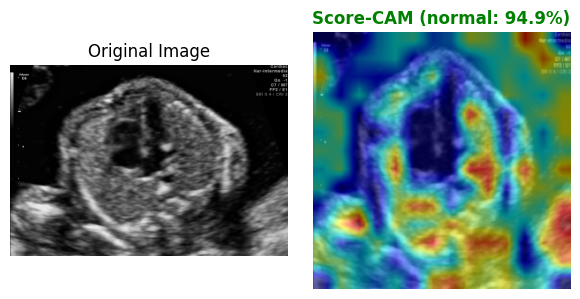

Generating Score-CAM for: 003_aug4.png
  → Prediction: ABNORMAL (96.87%)


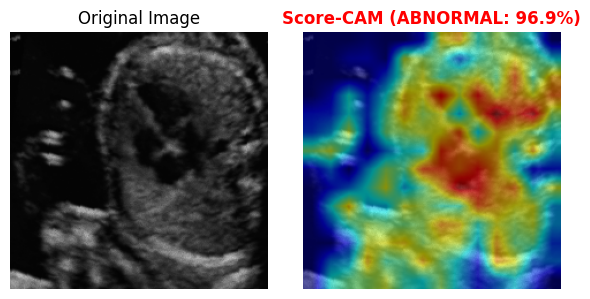

In [18]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Import the standalone model & inference logic we just perfected
from clean_predict import load_inference_model, infer_tf, DEVICE

# Import the ScoreCAM utilities from your src folder
from src.score_cam import ScoreCAM, show_cam_on_image

def generate_scorecam_heatmap(img_path, model, class_to_idx, threshold):
    print(f"Generating Score-CAM for: {os.path.basename(img_path)}")
    
    # 1. Prepare image
    img = Image.open(img_path).convert('RGB')
    input_tensor = infer_tf(img).unsqueeze(0).to(DEVICE)
    
    # 2. Get standard prediction first
    abnormal_idx = class_to_idx['abnormal']
    model.eval()
    with torch.no_grad():
        logits = model(input_tensor)
        probs = torch.softmax(logits, dim=1)[0]
        
    prob_abnormal = probs[abnormal_idx].item()
    if prob_abnormal >= threshold:
        label = 'ABNORMAL'
        confidence = prob_abnormal
    else:
        label = 'normal'
        confidence = probs[1 - abnormal_idx].item()
        
    print(f"  → Prediction: {label} ({confidence:.2%})")
    
    # 3. Setup Score-CAM
    # For Vision Transformers (ViT), we target the final transformer block
    target_layer = model.backbone.blocks[-1]
    
    # Initialize ScoreCAM wrapper
    score_cam = ScoreCAM(model, target_layer)
    
    # Generate Activation Map mask
    # We pass the predicted class index to generate the map for the predicted class
    predicted_class_idx = abnormal_idx if label == 'ABNORMAL' else (1 - abnormal_idx)
    cam_mask = score_cam.generate(input_tensor, class_idx=predicted_class_idx)
    
    # 4. Overlay heatmap onto the original image
    # Note: show_cam_on_image expects the normalized img_tensor to be shape (3, H, W)
    heatmap_overlay = show_cam_on_image(input_tensor[0], cam_mask, alpha=0.5)
    
    # 5. Plot and display
    plt.figure(figsize=(6, 3))
    
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title("Original Image")
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(heatmap_overlay)
    color = 'red' if label == 'ABNORMAL' else 'green'
    plt.title(f"Score-CAM ({label}: {confidence:.1%})", color=color, fontweight='bold')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

if __name__ == '__main__':
    # Load model and calibration
    model, c2i, thresh = load_inference_model('qvit_final_model.pth')
    
    # Example Image 1: Normal
    generate_scorecam_heatmap('heart_balanced/normal/034.png', model, c2i, thresh)
    
    # Example Image 2: Abnormal
    generate_scorecam_heatmap('heart_balanced/abnormal/003_aug4.png', model, c2i, thresh)


Generating Score-CAM for: 001.png
  → Prediction: normal (96.39%)


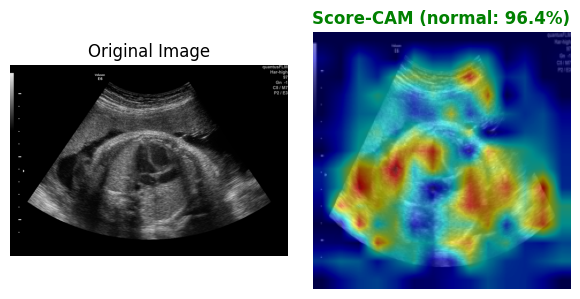

Generating Score-CAM for: 001_aug01.png
  → Prediction: ABNORMAL (17.08%)


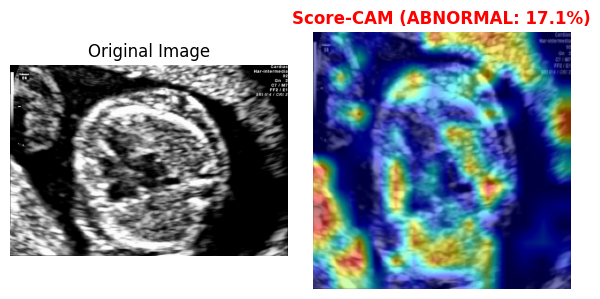

In [21]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Import the standalone model & inference logic we just perfected
from clean_predict import load_inference_model, infer_tf, DEVICE

# Import the ScoreCAM utilities from your src folder
from src.score_cam import ScoreCAM, show_cam_on_image

def generate_scorecam_heatmap(img_path, model, class_to_idx, threshold):
    print(f"Generating Score-CAM for: {os.path.basename(img_path)}")
    
    # 1. Prepare image
    img = Image.open(img_path).convert('RGB')
    input_tensor = infer_tf(img).unsqueeze(0).to(DEVICE)
    
    # 2. Get standard prediction first
    abnormal_idx = class_to_idx['abnormal']
    model.eval()
    with torch.no_grad():
        logits = model(input_tensor)
        probs = torch.softmax(logits, dim=1)[0]
        
    prob_abnormal = probs[abnormal_idx].item()
    if prob_abnormal >= threshold:
        label = 'ABNORMAL'
        confidence = prob_abnormal
    else:
        label = 'normal'
        confidence = probs[1 - abnormal_idx].item()
        
    print(f"  → Prediction: {label} ({confidence:.2%})")
    
    # 3. Setup Score-CAM
    # For Vision Transformers (ViT), we target the final transformer block
    target_layer = model.backbone.blocks[-1]
    
    # Initialize ScoreCAM wrapper
    score_cam = ScoreCAM(model, target_layer)
    
    # Generate Activation Map mask
    # We pass the predicted class index to generate the map for the predicted class
    predicted_class_idx = abnormal_idx if label == 'ABNORMAL' else (1 - abnormal_idx)
    cam_mask = score_cam.generate(input_tensor, class_idx=predicted_class_idx)
    
    # 4. Overlay heatmap onto the original image
    # Note: show_cam_on_image expects the normalized img_tensor to be shape (3, H, W)
    heatmap_overlay = show_cam_on_image(input_tensor[0], cam_mask, alpha=0.5)
    
    # 5. Plot and display
    plt.figure(figsize=(6, 3))
    
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title("Original Image")
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(heatmap_overlay)
    color = 'red' if label == 'ABNORMAL' else 'green'
    plt.title(f"Score-CAM ({label}: {confidence:.1%})", color=color, fontweight='bold')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

if __name__ == '__main__':
    # Load model and calibration
    model, c2i, thresh = load_inference_model('qvit_final_model.pth')
    
    # Example Image 1: Normal
    generate_scorecam_heatmap('heart_balanced/normal/001.png', model, c2i, thresh)
    
    # Example Image 2: Abnormal
    generate_scorecam_heatmap('heart_balanced_testing/abnormal/001_aug01.png', model, c2i, thresh)


Generating Score-CAM for: 118_aug6.png
  → Prediction: ABNORMAL (29.41%)


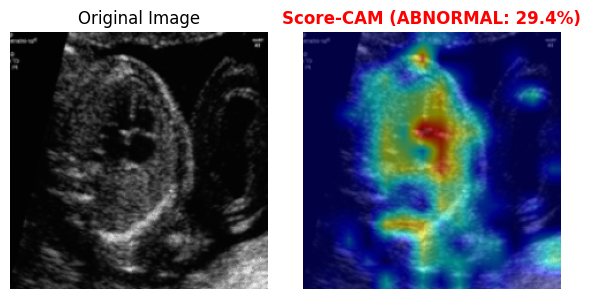

In [34]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Import the standalone model & inference logic we just perfected
from clean_predict import load_inference_model, infer_tf, DEVICE

# Import the ScoreCAM utilities from your src folder
from src.score_cam import ScoreCAM, show_cam_on_image

def generate_scorecam_heatmap(img_path, model, class_to_idx, threshold):
    print(f"Generating Score-CAM for: {os.path.basename(img_path)}")
    
    # 1. Prepare image
    img = Image.open(img_path).convert('RGB')
    input_tensor = infer_tf(img).unsqueeze(0).to(DEVICE)
    
    # 2. Get standard prediction first
    abnormal_idx = class_to_idx['abnormal']
    model.eval()
    with torch.no_grad():
        logits = model(input_tensor)
        probs = torch.softmax(logits, dim=1)[0]
        
    prob_abnormal = probs[abnormal_idx].item()
    if prob_abnormal >= threshold:
        label = 'ABNORMAL'
        confidence = prob_abnormal
    else:
        label = 'normal'
        confidence = probs[1 - abnormal_idx].item()
        
    print(f"  → Prediction: {label} ({confidence:.2%})")
    
    # 3. Setup Score-CAM
    # For Vision Transformers (ViT), we target the final transformer block
    target_layer = model.backbone.blocks[-1]
    
    # Initialize ScoreCAM wrapper
    score_cam = ScoreCAM(model, target_layer)
    
    # Generate Activation Map mask
    # We pass the predicted class index to generate the map for the predicted class
    predicted_class_idx = abnormal_idx if label == 'ABNORMAL' else (1 - abnormal_idx)
    cam_mask = score_cam.generate(input_tensor, class_idx=predicted_class_idx)
    
    # 4. Overlay heatmap onto the original image
    # Note: show_cam_on_image expects the normalized img_tensor to be shape (3, H, W)
    heatmap_overlay = show_cam_on_image(input_tensor[0], cam_mask, alpha=0.5)
    
    # 5. Plot and display
    plt.figure(figsize=(6, 3))
    
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title("Original Image")
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(heatmap_overlay)
    color = 'red' if label == 'ABNORMAL' else 'green'
    plt.title(f"Score-CAM ({label}: {confidence:.1%})", color=color, fontweight='bold')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

if __name__ == '__main__':
    # Load model and calibration
    model, c2i, thresh = load_inference_model('qvit_final_model.pth')
    
    # Example Image 2: Abnormal
    generate_scorecam_heatmap('heart_balanced/abnormal/118_aug6.png', model, c2i, thresh)


Generating Score-CAM for: 118_aug3.png
  → Prediction: ABNORMAL (82.61%)


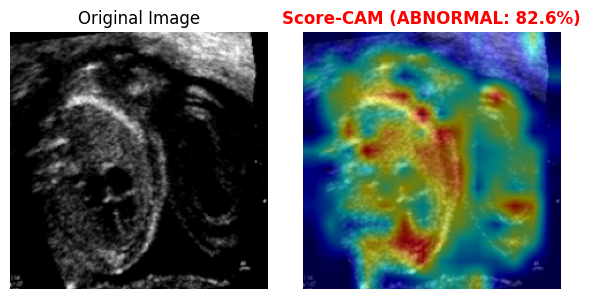

In [35]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Import the standalone model & inference logic we just perfected
from clean_predict import load_inference_model, infer_tf, DEVICE

# Import the ScoreCAM utilities from your src folder
from src.score_cam import ScoreCAM, show_cam_on_image

def generate_scorecam_heatmap(img_path, model, class_to_idx, threshold):
    print(f"Generating Score-CAM for: {os.path.basename(img_path)}")
    
    # 1. Prepare image
    img = Image.open(img_path).convert('RGB')
    input_tensor = infer_tf(img).unsqueeze(0).to(DEVICE)
    
    # 2. Get standard prediction first
    abnormal_idx = class_to_idx['abnormal']
    model.eval()
    with torch.no_grad():
        logits = model(input_tensor)
        probs = torch.softmax(logits, dim=1)[0]
        
    prob_abnormal = probs[abnormal_idx].item()
    if prob_abnormal >= threshold:
        label = 'ABNORMAL'
        confidence = prob_abnormal
    else:
        label = 'normal'
        confidence = probs[1 - abnormal_idx].item()
        
    print(f"  → Prediction: {label} ({confidence:.2%})")
    
    # 3. Setup Score-CAM
    # For Vision Transformers (ViT), we target the final transformer block
    target_layer = model.backbone.blocks[-1]
    
    # Initialize ScoreCAM wrapper
    score_cam = ScoreCAM(model, target_layer)
    
    # Generate Activation Map mask
    # We pass the predicted class index to generate the map for the predicted class
    predicted_class_idx = abnormal_idx if label == 'ABNORMAL' else (1 - abnormal_idx)
    cam_mask = score_cam.generate(input_tensor, class_idx=predicted_class_idx)
    
    # 4. Overlay heatmap onto the original image
    # Note: show_cam_on_image expects the normalized img_tensor to be shape (3, H, W)
    heatmap_overlay = show_cam_on_image(input_tensor[0], cam_mask, alpha=0.5)
    
    # 5. Plot and display
    plt.figure(figsize=(6, 3))
    
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title("Original Image")
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(heatmap_overlay)
    color = 'red' if label == 'ABNORMAL' else 'green'
    plt.title(f"Score-CAM ({label}: {confidence:.1%})", color=color, fontweight='bold')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

if __name__ == '__main__':
    # Load model and calibration
    model, c2i, thresh = load_inference_model('qvit_final_model.pth')
    
    # Example Image 2: Abnormal
    generate_scorecam_heatmap('heart_balanced/abnormal/118_aug3.png', model, c2i, thresh)
